First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

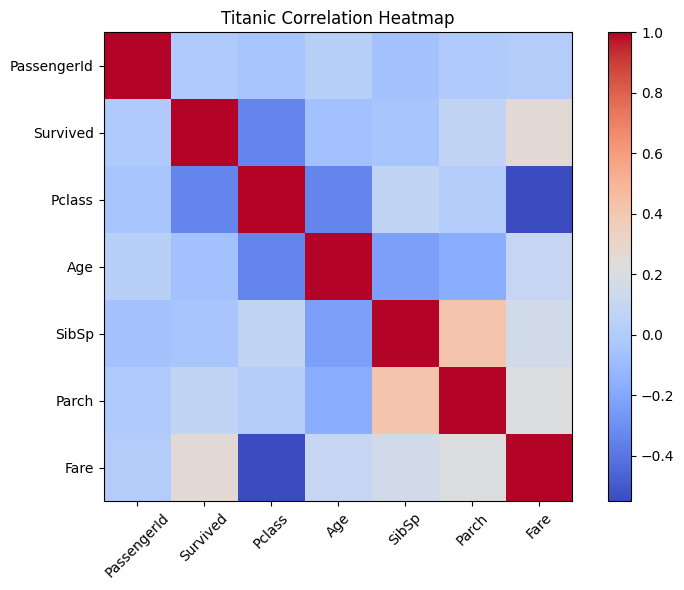

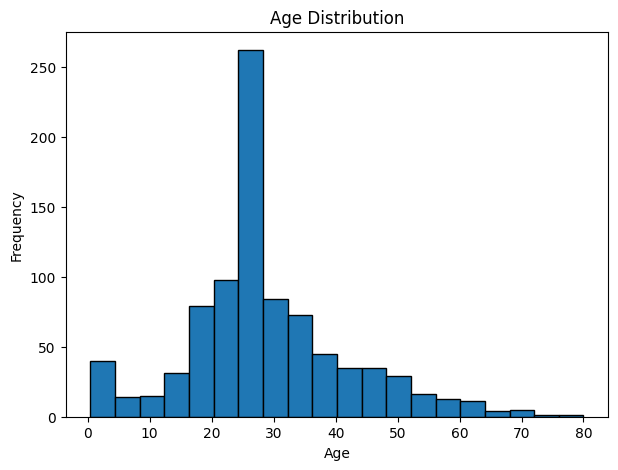

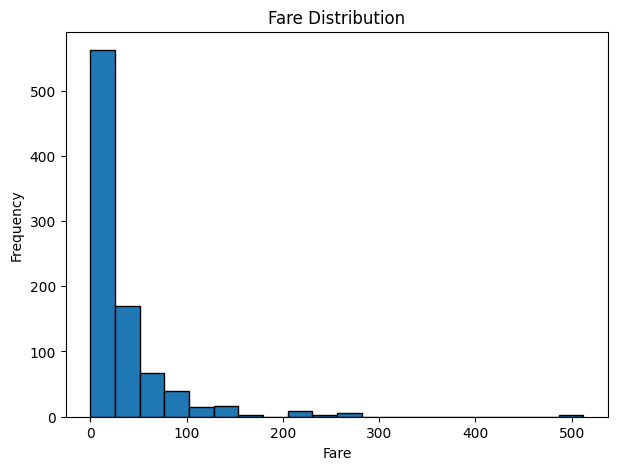

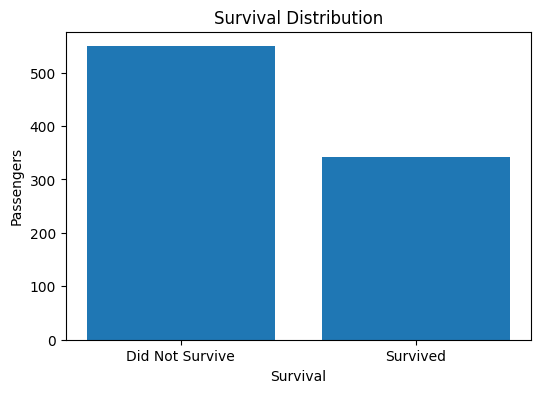


EDA completed successfully!


In [ ]:
# Titanic Dataset - Data Cleaning and EDA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("First 5 rows:")
print(df.head())

print("\nShape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

# 2. Data Cleaning
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop(columns=["Cabin"], inplace=True)
df.drop_duplicates(inplace=True)

print("\nAfter Cleaning:")
print(df.isnull().sum())

# 3. Summary Statistics
print("\nSummary Statistics:")
print(df.describe())

# 4. Value Counts
print("\nSex:")
print(df["Sex"].value_counts())

print("\nSurvival:")
print(df["Survived"].value_counts())

# 5. Correlation Heatmap
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Titanic Correlation Heatmap")
plt.tight_layout()
plt.show()

# 6. Age Histogram
plt.figure(figsize=(7, 5))
plt.hist(df["Age"], bins=20, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

# 7. Fare Histogram
plt.figure(figsize=(7, 5))
plt.hist(df["Fare"], bins=20, edgecolor="black")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Fare Distribution")
plt.show()

# 8. Survival Bar Graph
survival = df["Survived"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Did Not Survive", "Survived"], survival.values)
plt.xlabel("Survival")
plt.ylabel("Passengers")
plt.title("Survival Distribution")
plt.show()

print("\nEDA completed successfully!")